In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import json

## Dataset

In [2]:
class StructureImageDataset(Dataset):
    """
    Dataset for structure–image pairs (unified multimodal DTI space)
    Reads:
      - data.csv with columns: structure, image, id
      - four .pt files:
          drug_structure.pt, drug_image.pt,
          protein_structure.pt, protein_image.pt
    Automatically converts string IDs → integer indices (stable across runs)
    """

    def __init__(self, csv_path, drug_struct_path, drug_img_path, prot_struct_path, prot_img_path):
        # ---- Load data ----
        self.data = pd.read_csv(csv_path)
        print(f"✅ Loaded CSV with {len(self.data)} rows.")

        # ---- Load embedding dictionaries ----
        self.drug_structure = torch.load(drug_struct_path, weights_only=True)
        self.drug_image = torch.load(drug_img_path, weights_only=True)
        self.protein_structure = torch.load(prot_struct_path, weights_only=True)
        self.protein_image = torch.load(prot_img_path, weights_only=True)

        # ---- Build stable string→int mapping for IDs ----
        unique_ids = sorted(self.data["id"].unique())
        self.id_to_int = {x: i for i, x in enumerate(unique_ids)}
        print(f"✅ Encoded {len(unique_ids)} unique IDs.")

    def __len__(self):
        return len(self.data)

    def _get_embedding(self, key, column_type):
        """
        Decide which embedding dictionary to use based on the column role.
        'column_type' is either 'structure' or 'image'.
        """
        if column_type == "structure":
            # structure column always uses structure embeddings
            if key in self.drug_structure:
                return self.drug_structure[key]
            elif key in self.protein_structure:
                return self.protein_structure[key]
        elif column_type == "image":
            # image column always uses image embeddings
            if key in self.drug_image:
                return self.drug_image[key]
            elif key in self.protein_image:
                return self.protein_image[key]

        raise KeyError(f"Key {key[:30]}... not found in any {column_type} dict.")

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        struct_key = row["structure"]
        image_key = row["image"]
        pair_id = row["id"]

        # Get embeddings
        struct_embed = self._get_embedding(struct_key, "structure")
        image_embed = self._get_embedding(image_key, "image")

        # Convert ID → int index
        id_numeric = self.id_to_int[pair_id]

        return {
            "structure": struct_embed,
            "image": image_embed,
            "structure_key": struct_key,
            "image_key": image_key,
            "id": id_numeric,  # now numeric and deterministic
        }


In [50]:
train_dataset = StructureImageDataset(
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/processed/train_pairs.csv',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_smile_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_drug_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_protein_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_protein_embeddings.pt'
)

✅ Loaded CSV with 61168 rows.
✅ Encoded 15292 unique IDs.


In [3]:
test_dataset = StructureImageDataset(
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/processed/test_pairs.csv',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_smile_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_drug_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_protein_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_protein_embeddings.pt'
)

✅ Loaded CSV with 22984 rows.
✅ Encoded 5746 unique IDs.


## Projection Head

In [4]:
class ProjectionHead(nn.Module):
    """Deeper MLP projection head for contrastive learning."""
    
    def __init__(self, input_dim, hidden_dim=1024, output_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

## Model

In [5]:
class ContrastiveModel(nn.Module):
    """Contrastive learning model for drug-target alignment"""
    
    def __init__(self, input_dim = 512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.struct_projector = ProjectionHead(input_dim, hidden_dim, output_dim)
        self.img_projector = ProjectionHead(input_dim, hidden_dim, output_dim)
        
    def forward(self, struct_embeds, img_embeds):
        struct_proj = self.struct_projector(struct_embeds)
        img_proj = self.img_projector(img_embeds)
        return struct_proj, img_proj

## Loss function

In [7]:
class MultiPositiveInfoNCELoss(nn.Module):
    """InfoNCE loss for multi-positive contrastive learning"""
    
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, struct_proj, img_proj, labels):
        """
        Compute bidirectional InfoNCE loss with multi-positive pairs
        Args:
            modality1_proj: [batch_size, proj_dim] normalized modality1 projections
            modality2_proj: [batch_size, proj_dim] normalized modality2 projections
            labels: [batch_size] label_ID for each sample
        """
        batch_size = struct_proj.shape[0]
        device = struct_proj.device
        
        # Compute similarity matrix [batch_size, batch_size]
        logits = torch.matmul(struct_proj, img_proj.T) / self.temperature
        
        # Create positive mask: mask[i,j] = 1 if labels[i] == labels[j]
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)
        
        # Modality1-to-Modality2 loss
        loss_m1_to_m2 = self.compute_loss(logits, mask)
        
        # Modality2-to-Modality1 loss
        loss_m2_to_m1 = self.compute_loss(logits.T, mask.T)
        
        # Symmetric loss
        loss = (loss_m1_to_m2 + loss_m2_to_m1) / 2
        
        return loss
    
    def compute_loss(self, logits, mask):
        """
        Compute InfoNCE loss for one direction
        Args:
            logits: [batch_size, batch_size] similarity matrix
            mask: [batch_size, batch_size] positive pair mask
        """
        # Subtract max for numerical stability
        logits_max, _ = torch.max(logits, dim=1, keepdim=True)
        logits = logits - logits_max.detach()
        
        # Compute exp of logits
        exp_logits = torch.exp(logits)
        
        # Sum of exp logits (denominator)
        sum_exp_logits = exp_logits.sum(1, keepdim=True)
        
        # Log probabilities
        log_prob = logits - torch.log(sum_exp_logits)
        
        # Compute mean of log-likelihood over positive pairs
        # mask.sum(1) gives number of positives for each sample
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)
        
        # Loss is negative log-likelihood
        loss = -mean_log_prob_pos.mean()
        
        return loss

## Compute metrics during training

In [8]:
def compute_alignment_metrics(struct_proj, img_proj, labels):
    """
    Compute alignment metrics for multi-positive pairs
    Args:
        modality1_proj: [batch_size, proj_dim] normalized projections
        modality2_proj: [batch_size, proj_dim] normalized projections
        labels: [batch_size] label_ID for each sample
    Returns:
        dict with metrics
    """
    batch_size = struct_proj.shape[0]
    device = struct_proj.device
    
    # Compute full similarity matrix
    sim_matrix = torch.matmul(struct_proj, img_proj.T)  # [batch_size, batch_size]
    
    # Create positive mask: mask[i,j] = 1 if labels[i] == labels[j]
    labels = labels.contiguous().view(-1, 1)
    pos_mask = torch.eq(labels, labels.T).float().to(device)
    neg_mask = 1 - pos_mask
    
    # Positive similarities (same label_ID)
    pos_sim = sim_matrix[pos_mask.bool()]
    
    # Negative similarities (different label_ID)
    neg_sim = sim_matrix[neg_mask.bool()]
    
    metrics = {
        'pos_sim_mean': pos_sim.mean().item() if len(pos_sim) > 0 else 0.0,
        'neg_sim_mean': neg_sim.mean().item() if len(neg_sim) > 0 else 0.0,
        'gap': (pos_sim.mean() - neg_sim.mean()).item() if len(pos_sim) > 0 and len(neg_sim) > 0 else 0.0,
        'alignment': pos_sim.mean().item() if len(pos_sim) > 0 else 0.0
    }
    
    return metrics

## Training

In [9]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    # Metrics accumulators
    metrics_accumulator = {'pos_sim_mean': 0,'neg_sim_mean': 0,'gap': 0,'alignment': 0}
    
    for batch in tqdm(dataloader, desc="Training"):
        struct_embeds = batch['structure'].to(device)
        img_embeds = batch['image'].to(device)
        label = torch.tensor(batch['id'], dtype=torch.long).to(device)
        
        # Forward pass
        struct_proj, img_proj = model(struct_embeds, img_embeds)
        
        # Compute loss
        loss = criterion(struct_proj, img_proj, label)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Compute metrics (no grad needed)
        with torch.no_grad():
            batch_metrics = compute_alignment_metrics(struct_proj, img_proj, label)
            for key in metrics_accumulator:
                metrics_accumulator[key] += batch_metrics[key]
    
    # Average metrics
    avg_loss = total_loss / len(dataloader)
    avg_metrics = {k: v / len(dataloader) for k, v in metrics_accumulator.items()}
    
    return avg_loss, avg_metrics

In [10]:
def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    
    # Metrics accumulators
    metrics_accumulator = {'pos_sim_mean': 0,'neg_sim_mean': 0,'gap': 0,'alignment': 0}
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            struct_embeds = batch['structure'].to(device)
            img_embeds = batch['image'].to(device)
            label = torch.tensor(batch['id'], dtype=torch.long).to(device)
            
            struct_proj, img_proj = model(struct_embeds, img_embeds)
            loss = criterion(struct_proj, img_proj, label)
            
            total_loss += loss.item()
            
            # Compute metrics
            batch_metrics = compute_alignment_metrics(struct_proj, img_proj, label)
            for key in metrics_accumulator:
                metrics_accumulator[key] += batch_metrics[key]
    
    avg_loss = total_loss / len(dataloader)
    avg_metrics = {k: v / len(dataloader) for k, v in metrics_accumulator.items()}
    
    return avg_loss, avg_metrics

In [16]:
def main():
    # Configuration
    config = {
        'batch_size': 256,
        'learning_rate': 1e-5,
        'num_epochs': 30,
        'hidden_dim': 1024,
        'output_dim': 512,
        'temperature': 0.10,
        'weight_decay': 1e-3,
        'save_dir': '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/result/0102/',
        'device': 'cuda' if torch.cuda.is_available() else 'cpu'
    }
    
    print(f"Using device: {config['device']}")
     
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    
    # Get embedding dimensions from first sample
    sample = train_dataset[0]
    struct_dim = sample['structure'].shape[0]
    img_dim = sample['image'].shape[0]
    print(f"Structure embedding dim: {struct_dim}, Image embedding dim: {img_dim}")
    
    # Initialize model
    model = ContrastiveModel(
        input_dim=struct_dim,
        hidden_dim=config['hidden_dim'],
        output_dim=config['output_dim']
    ).to(config['device'])
    
    # Loss and optimizer
    criterion = MultiPositiveInfoNCELoss(temperature=config['temperature'])
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['num_epochs']
    )
    
    # Training loop
    best_val_loss = float('inf')
    history = []
    
    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        train_loss, train_metrics = train_epoch(model, train_loader, optimizer, criterion, config['device'])
        val_loss, val_metrics = validate(model, val_loader, criterion, config['device'])
        
        scheduler.step()
        
        # Save to history
        epoch_record = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_pos': train_metrics['pos_sim_mean'],
            'train_neg': train_metrics['neg_sim_mean'],
            'train_gap': train_metrics['gap'],
            'train_alignment': train_metrics['alignment'],
            'val_loss': val_loss,
            'val_pos': val_metrics['pos_sim_mean'],
            'val_neg': val_metrics['neg_sim_mean'],
            'val_gap': val_metrics['gap'],
            'val_alignment': val_metrics['alignment']
        }
        history.append(epoch_record)
        
        # Print loss
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        # Print alignment metrics
        print(f"Train Metrics - Pos Sim: {train_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {train_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {train_metrics['gap']:.4f}, "
              f"Alignment: {train_metrics['alignment']:.4f}")
        
        print(f"Val Metrics   - Pos Sim: {val_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {val_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {val_metrics['gap']:.4f}, "
              f"Alignment: {val_metrics['alignment']:.4f}")
        
        # ---- Save best model ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"{config['save_dir']}/best_model.pt")
            print(f"🏆 New best model saved (val_loss={val_loss:.4f})")
        
        # Save history every epoch
        with open(f"{config['save_dir']}/training_history.json", 'w') as f:
            json.dump(history, f, indent=2)
    
    print("\nTraining completed!")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Training history saved to: training_history.json")

In [17]:
if __name__ == '__main__':
    main()

Using device: cuda
Structure embedding dim: 512, Image embedding dim: 512

Epoch 1/30


/scratch/slurm-1562169/ipykernel_3731542/393560556.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(batch['id'], dtype=torch.long).to(device)
Training: 100%|██████████| 239/239 [00:03<00:00, 69.08it/s]
/scratch/slurm-1562169/ipykernel_3731542/3699923083.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(batch['id'], dtype=torch.long).to(device)
Validating: 100%|██████████| 90/90 [00:00<00:00, 130.06it/s]


Train Loss: 4.4792, Val Loss: 3.6372
Train Metrics - Pos Sim: 0.1647, Neg Sim: 0.0021, Gap: 0.1626, Alignment: 0.1647
Val Metrics   - Pos Sim: 0.3846, Neg Sim: 0.0104, Gap: 0.3743, Alignment: 0.3846
🏆 New best model saved (val_loss=3.6372)

Epoch 2/30


Validating: 100%|██████████| 90/90 [00:00<00:00, 130.61it/s]


Train Loss: 3.5341, Val Loss: 3.3381
Train Metrics - Pos Sim: 0.3480, Neg Sim: 0.0048, Gap: 0.3432, Alignment: 0.3480
Val Metrics   - Pos Sim: 0.4866, Neg Sim: 0.0071, Gap: 0.4795, Alignment: 0.4866
🏆 New best model saved (val_loss=3.3381)

Epoch 3/30


...

Train Loss: 2.4083, Val Loss: 3.0120
Train Metrics - Pos Sim: 0.5275, Neg Sim: -0.0018, Gap: 0.5293, Alignment: 0.5275
Val Metrics   - Pos Sim: 0.6212, Neg Sim: 0.0074, Gap: 0.6138, Alignment: 0.6212

Epoch 29/30


Validating: 100%|██████████| 90/90 [00:00<00:00, 130.69it/s]


Train Loss: 2.4084, Val Loss: 3.0123
Train Metrics - Pos Sim: 0.5274, Neg Sim: -0.0018, Gap: 0.5292, Alignment: 0.5274
Val Metrics   - Pos Sim: 0.6212, Neg Sim: 0.0077, Gap: 0.6135, Alignment: 0.6212

Epoch 30/30


Validating: 100%|██████████| 90/90 [00:00<00:00, 130.76it/s]

Train Loss: 2.4048, Val Loss: 3.0142
Train Metrics - Pos Sim: 0.5279, Neg Sim: -0.0018, Gap: 0.5296, Alignment: 0.5279
Val Metrics   - Pos Sim: 0.6213, Neg Sim: 0.0072, Gap: 0.6141, Alignment: 0.6213

Training completed!
Best validation loss: 3.0119
Training history saved to: training_history.json


## Inference

In [6]:
import random
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import umap
import seaborn as sns

In [7]:
device = 'cpu'
model = ContrastiveModel(input_dim = 512, hidden_dim=1024, output_dim=512)
model.load_state_dict(torch.load("/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/result/0102/best_model.pt", map_location=device))
model.to(device)
model.eval()

/scratch/slurm-1604521/ipykernel_2744209/3262331512.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/ix1/ychiu/yil346/DTI_v2/Unified/co

ContrastiveModel(
  (struct_projector): ProjectionHead(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=1024, out_features=512, bias=True)
      (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (img_projector): ProjectionHead(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=1024, out_features=512, bias=True)
      (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_ru

In [8]:
test_dataset = StructureImageDataset(
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/processed/test_pairs.csv',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_smile_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_drug_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_protein_embeddings.pt',
    '/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_protein_embeddings.pt'
)

val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

✅ Loaded CSV with 22984 rows.
✅ Encoded 5746 unique IDs.


In [9]:
#val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
#val_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)

drug_image_dict = torch.load('/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_drug_embeddings.pt')
protein_image_dict = torch.load('/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_img_protein_embeddings.pt')
drug_structure_dict = torch.load('/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_smile_embeddings.pt')
protein_structure_dict = torch.load('/ix1/ychiu/yil346/DTI_v2/Unified/contrastive_learning/random_split/data/embeddings/contrastive_new_protein_embeddings.pt')

/scratch/slurm-1604521/ipykernel_2744209/84185052.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  drug_image_dict = torch.load('/ix1/ychiu/yil346/DTI_v2/Unified/contrast

In [56]:
# === Initialize output container for new projected embeddings ===
embeddings = {
    "drug_structure": {},
    "drug_image": {},
    "target_structure": {},
    "target_image": {}
}

model.eval()
with torch.no_grad():
    for batch in val_loader:
        struct_embeds = batch["structure"].to(device)
        img_embeds = batch["image"].to(device)
        struct_keys = batch["structure_key"]
        img_keys = batch["image_key"]

        # Forward pass through the trained projection model
        struct_features, img_features = model(struct_embeds, img_embeds)
        struct_features = struct_features.cpu()
        img_features = img_features.cpu()

        for s_key, i_key, s_vec, i_vec in zip(struct_keys, img_keys, struct_features, img_features):

            # --- Identify which modality the structure key belongs to ---
            if s_key in drug_structure_dict:
                embeddings["drug_structure"][s_key] = s_vec
            elif s_key in protein_structure_dict:
                embeddings["target_structure"][s_key] = s_vec
            elif s_key in drug_image_dict:
                # Rare but possible if image and structure share identifiers
                embeddings["drug_image"][s_key] = s_vec
            elif s_key in protein_image_dict:
                embeddings["target_image"][s_key] = s_vec
            else:
                print(f"[Warning] structure key not found in any dict: {s_key[:20]}...")

            # --- Identify which modality the image key belongs to ---
            if i_key in drug_image_dict:
                embeddings["drug_image"][i_key] = i_vec
            elif i_key in protein_image_dict:
                embeddings["target_image"][i_key] = i_vec
            elif i_key in drug_structure_dict:
                embeddings["drug_structure"][i_key] = i_vec
            elif i_key in protein_structure_dict:
                embeddings["target_structure"][i_key] = i_vec
            else:
                print(f"[Warning] image key not found in any dict: {i_key[:20]}...")

print("✅ Collected embeddings for 4 modalities:")
for k, v in embeddings.items():
    print(f"{k}: {len(v)} entries")

# === Save everything together ===
torch.save(embeddings, "unified_embeddings.pt")
print("💾 Saved to unified_embeddings.pt")

✅ Collected embeddings for 4 modalities:
drug_structure: 1815 entries
drug_image: 1815 entries
target_structure: 2312 entries
target_image: 2312 entries
💾 Saved to unified_embeddings.pt


In [22]:
def show_first(modality_name):
    subdict = embeddings[modality_name]
    key, value = next(iter(subdict.items()))
    print(f"\n🔸 {modality_name}")
    print(f"Key (first 50 chars): {key[:50]}{'...' if len(key) > 50 else ''}")
    print(f"Embedding shape: {tuple(value.shape)}")
    print(f"First 10 dimensions:\n{value[:10]}")
    print("-" * 80)

# Display first element for each modality
for modality in ["drug_structure", "drug_image", "target_structure", "target_image"]:
    show_first(modality)


🔸 drug_structure
Key (first 50 chars): CN(C)CCC(c1ccc(Br)cc1)c1ccccn1
Embedding shape: (512,)
First 10 dimensions:
tensor([ 0.0189, -0.0259, -0.0612, -0.0732,  0.0015, -0.0245, -0.0655, -0.0065,
        -0.0674,  0.0041])
--------------------------------------------------------------------------------

🔸 drug_image
Key (first 50 chars): CN(C)CCC(c1ccc(Br)cc1)c1ccccn1
Embedding shape: (512,)
First 10 dimensions:
tensor([ 0.0341, -0.0774, -0.0610, -0.0525,  0.0006,  0.0014, -0.0618, -0.0177,
        -0.0800, -0.0222])
--------------------------------------------------------------------------------

🔸 target_structure
Key (first 50 chars): MEGDSYHNATTVNGTPVNHQPLERHRLWEVITIAAVTAVVSLITIVGNVL...
Embedding shape: (512,)
First 10 dimensions:
tensor([ 0.0033, -0.0415, -0.0037, -0.0170, -0.0431, -0.0274, -0.0282, -0.0885,
        -0.0452,  0.0461])
--------------------------------------------------------------------------------

🔸 target_image
Key (first 50 chars): MEGDSYHNATTVNGTPVNHQPLERHRLWE

In [10]:
embs = torch.load("unified_embeddings.pt")
drug_struct_embs = embs["drug_structure"]
drug_img_embs = embs["drug_image"]
protein_struct_embs = embs["target_structure"]
protein_img_embs = embs["target_image"]

/scratch/slurm-1604521/ipykernel_2744209/783383230.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embs = torch.load("unified_embeddings.pt")


In [11]:
def collect_val_similarities(model, dataloader, device):
    """
    Collect all positive and negative similarities across validation set
    Returns:
        all_pos_sim: Tensor [N_pos]
        all_neg_sim: Tensor [N_neg]
    """
    model.eval()
    
    all_pos_sim = []
    all_neg_sim = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Collecting validation similarities"):
            
            struct_embeds = batch['structure'].to(device)
            img_embeds = batch['image'].to(device)
            labels = torch.tensor(batch['id'], dtype=torch.long).to(device)
            
            struct_proj, img_proj = model(struct_embeds, img_embeds)
            
            # similarity matrix
            sim_matrix = torch.matmul(struct_proj, img_proj.T)
            
            labels = labels.view(-1, 1)
            pos_mask = torch.eq(labels, labels.T)
            neg_mask = ~pos_mask
            
            pos_sim = sim_matrix[pos_mask]
            neg_sim = sim_matrix[neg_mask]
            
            if len(pos_sim) > 0:
                all_pos_sim.append(pos_sim.cpu())
            if len(neg_sim) > 0:
                all_neg_sim.append(neg_sim.cpu())
    
    all_pos_sim = torch.cat(all_pos_sim)
    all_neg_sim = torch.cat(all_neg_sim)
    
    return all_pos_sim, all_neg_sim


In [12]:
val_pos_sim, val_neg_sim = collect_val_similarities(model, val_loader, device)
print("Positive mean:", val_pos_sim.mean().item())
print("Negative mean:", val_neg_sim.mean().item())

/scratch/slurm-1604521/ipykernel_2744209/639928635.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['id'], dtype=torch.long).to(device)

Positive mean: 0.621309757232666
Negative mean: 0.008172687143087387


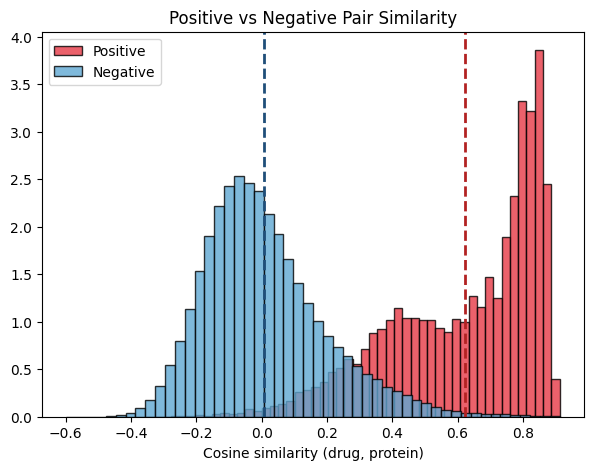

In [14]:
plt.figure(figsize=(7, 5))

plt.hist(val_pos_sim, bins=50, color='#e63946', alpha=0.8, label='Positive', density=True, edgecolor='black')
plt.hist(val_neg_sim, bins=50, color='#5fa8d3', alpha=0.8, label='Negative', density=True, edgecolor='black')

plt.axvline(val_pos_sim.mean(), color='#b22222', linestyle='--', linewidth=2)
plt.axvline(val_neg_sim.mean(), color='#1f4e79', linestyle='--', linewidth=2)


plt.legend()
plt.xlabel("Cosine similarity (drug, protein)")
plt.title("Positive vs Negative Pair Similarity")
#plt.savefig("/ix1/ychiu/yil346/DTI_v2/plot/unified_cosine_similarity_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [15]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(val_pos_sim, val_neg_sim)
print("t-statistic:", t_stat)
print("p-value:", p_value)

u_stat, p_value = stats.mannwhitneyu(val_pos_sim, val_neg_sim, alternative='two-sided')
print("U statistic:", u_stat)
print("p-value:", p_value)

t-statistic: 983.4325049688915
p-value: 0.0
U statistic: 514911136928.0
p-value: 0.0
